# Cross-correlations from four stations, three archives

Two months of vertical-component noise (January–February 2022) from four
southern/central California broadband stations spanning **three cloud
archives**, with seisfetch as the only data client:

| Station | Network | Archive | Pair with PASC |
|---|---|---|---|
| PASC (Pasadena) | CI | **SCEDC** open data (`scedc-pds`) | — |
| RPV (Rancho Palos Verdes) | CI | **SCEDC** open data (`scedc-pds`) | 52 km, across the LA basin |
| PFO (Piñon Flat) | II | **EarthScope** open data (`earthscope-open-data`) | 172 km |
| PKD (Parkfield) | BK | **NCEDC** open data (`ncedc-pds`) | 291 km (PKD–PFO: 455 km) |

Everything below is obspy-free: seisfetch fetch + parse, the
`noisepy_adapter` preprocessing ports, then **NoisePy's own**
`compute_fft` / `correlate` for the cross-correlations.

The companion harness `benchmarks/noisepy_eval/run_xcorr_eval.py` runs this
exact pipeline side-by-side with the obspy-fed NoisePy path: the daily CCFs
are **bit-identical** (max abs difference 0.0) for all three pairs
(`benchmarks/results/xcorr_three_archives_2022-01-02.json`).


In [1]:
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from seisfetch.convert import parse_mseed
from seisfetch.s3 import S3OpenClient

warnings.filterwarnings("ignore")

DAYS = [f"2022-01-{d:02d}" for d in range(1, 32)] + [
    f"2022-02-{d:02d}" for d in range(1, 29)
]
SHOW_DAY = "2022-01-02"
CACHE = Path("..") / ".xcorr_eval_cache"  # day files cached on first run

STATIONS = {
    # sta: (datacenter, net, loc, cha, lat, lon)
    "PASC": ("scedc", "CI", "00", "BHZ", 34.1714, -118.1865),
    "RPV": ("scedc", "CI", "", "BHZ", 33.7438, -118.4043),
    "PKD": ("ncedc", "BK", "00", "BHZ", 35.9452, -120.5416),
    "PFO": ("earthscope", "II", "00", "BHZ", 33.6092, -116.4553),
}
ARCHIVE_LABEL = {
    "scedc": "SCEDC S3",
    "ncedc": "NCEDC S3",
    "earthscope": "EarthScope S3",
}
COLORS = {"PASC": "#2a78d6", "RPV": "#8a5cd6", "PKD": "#eb6834", "PFO": "#1baf7a"}

CACHE.mkdir(exist_ok=True)
clients = {dc: S3OpenClient(datacenter=dc) for dc in ARCHIVE_LABEL}


def fetch_day(sta, day):
    dc, net, loc, cha, *_ = STATIONS[sta]
    # cache key encodes the datacenter and channel selection so a rerun with
    # different parameters can never silently reuse the wrong bytes
    sel = "all" if dc == "earthscope" else f"{loc or '--'}.{cha}"
    f = CACHE / f"{dc}.{net}.{sta}.{sel}.{day}.ms"
    if not f.exists():
        # EarthScope stores whole station-day objects; SCEDC/NCEDC per-channel
        kwargs = {} if dc == "earthscope" else {"location": loc, "channel": cha}
        f.write_bytes(clients[dc].get_raw(net, sta, day, **kwargs))
    return f.read_bytes()


raw = {}
for sta in STATIONS:
    for day in DAYS:
        try:
            raw[(sta, day)] = fetch_day(sta, day)
        except Exception as e:
            print(f"{sta} {day}: no data ({type(e).__name__})")
for sta in STATIONS:
    dc = STATIONS[sta][0]
    have = [d for d in DAYS if (sta, d) in raw]
    mb = sum(len(raw[(sta, d)]) for d in have) / 1e6
    print(f"{sta}: {len(have)}/{len(DAYS)} days, {mb:7.1f} MB from {ARCHIVE_LABEL[dc]}")

PASC: 59/59 days,   412.1 MB from SCEDC S3
RPV: 59/59 days,   375.7 MB from SCEDC S3
PKD: 59/59 days,   226.4 MB from NCEDC S3
PFO: 59/59 days,  1536.7 MB from EarthScope S3


In [2]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


PAIRS = [("PASC", "RPV"), ("PASC", "PFO"), ("PASC", "PKD"), ("PKD", "PFO")]
DIST = {(s, r): haversine_km(*STATIONS[s][4:6], *STATIONS[r][4:6]) for s, r in PAIRS}
for (s, r), d in DIST.items():
    print(f"{s}-{r}: {d:6.1f} km")

PASC-RPV:   51.6 km
PASC-PFO:  171.6 km
PASC-PKD:  291.3 km
PKD-PFO:  454.6 km


## Raw waveforms, one hour per station

Each trace comes straight out of `parse_mseed` on the bytes of a different
archive. A 0.1–1 Hz bandpass (the adapter's own `bandpass_np`) makes the
microseism wavefield visible.


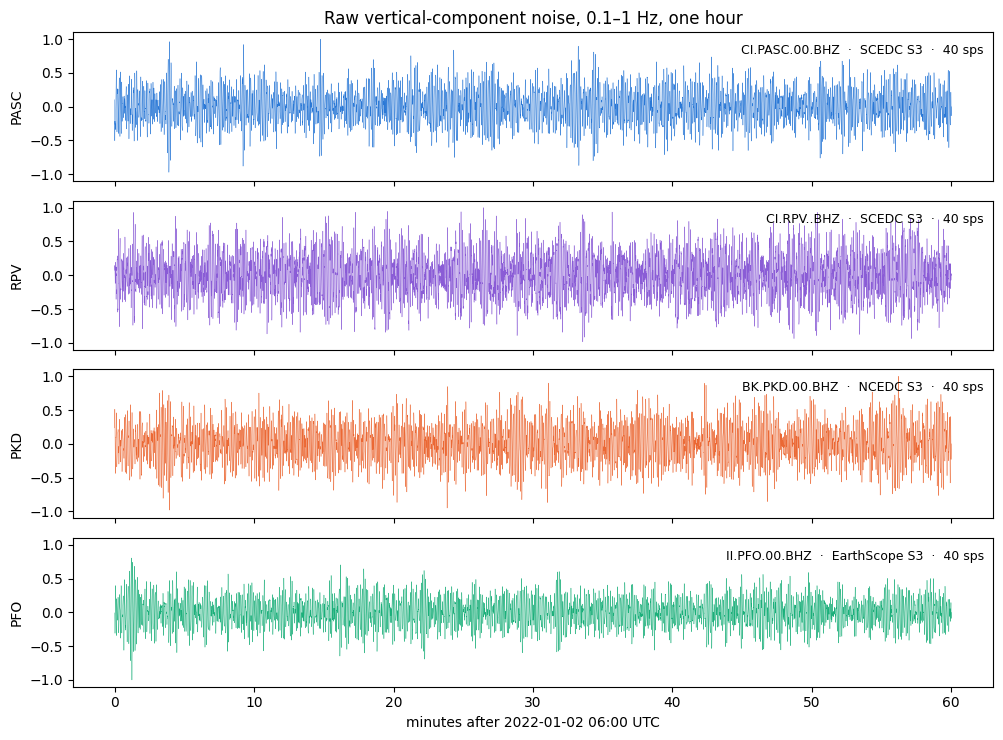

In [3]:
from seisfetch.contrib.noisepy_adapter import bandpass_np

show0 = datetime.fromisoformat(SHOW_DAY).replace(tzinfo=timezone.utc)
HOUR = 6  # 06:00-07:00 UTC

fig, axes = plt.subplots(len(STATIONS), 1, figsize=(10, 7.5), sharex=True)
for ax, sta in zip(axes, STATIONS):
    dc, net, loc, cha, *_ = STATIONS[sta]
    nslc = f"{net}.{sta}.{loc}.{cha}"
    seg = parse_mseed(raw[(sta, SHOW_DAY)]).segments()[nslc][0]
    fs = seg.sampling_rate
    i0 = int(round((show0.timestamp() + HOUR * 3600 - seg.starttime_ns / 1e9) * fs))
    x = seg.data[i0 : i0 + int(3600 * fs)].astype(np.float64)
    x = bandpass_np(x - x.mean(), 0.1, 1.0, df=fs, corners=4, zerophase=True)
    t = np.arange(x.size) / fs / 60.0
    ax.plot(t, x / np.abs(x).max(), lw=0.3, color=COLORS[sta])
    ax.set_ylabel(sta)
    ax.set_ylim(-1.1, 1.1)
    ax.text(
        0.99,
        0.92,
        f"{nslc}  ·  {ARCHIVE_LABEL[dc]}  ·  {fs:.0f} sps",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )
axes[-1].set_xlabel(f"minutes after {SHOW_DAY} {HOUR:02d}:00 UTC")
axes[0].set_title("Raw vertical-component noise, 0.1–1 Hz, one hour")
fig.tight_layout()

## NoisePy cross-correlations, day by day

Preprocessing runs through `preprocess_raw_np` (the obspy-free port of
NoisePy's `preprocess_raw` at `rm_resp=NO`), targeting 20 sps so the
Fourier-resample branch is exercised; the FFTs and correlations are
NoisePy's own `compute_fft` and `noise_module.correlate` — the same code the
production pipeline runs. Archive day files start sub-sample off midnight
(PASC is 0.218 samples off), so each window is snapped to its channel's
sample grid first, as the adapter's alignment guard requires.

One-bit time normalization and running-mean spectral whitening, 1800-s
windows with 450-s step: 188 windows per station-day.


In [4]:
import sys

sys.path.insert(0, str(Path("..") / "benchmarks" / "noisepy_eval"))
from noisepy.seis.io.datatypes import (
    CCMethod,
    ConfigParameters,
    FreqNorm,
    RmResp,
    TimeNorm,
)
from run_ccf_eval import daily_ccf, path_b, snap_window

cfg = ConfigParameters(
    sampling_rate=20.0,
    cc_len=1800,
    step=450,
    maxlag=500.0,
    freqmin=0.05,
    freqmax=9.0,
    acorr_only=False,
    rm_resp=RmResp.NO,
    cc_method=CCMethod.XCORR,
    freq_norm=FreqNorm.RMA,
    time_norm=TimeNorm.ONE_BIT,
    substack=False,
)

daily = {p: {} for p in PAIRS}
for day in DAYS:
    day0 = datetime.fromisoformat(day).replace(tzinfo=timezone.utc)
    day1 = day0 + timedelta(days=1)
    ffts = {}
    for sta in STATIONS:
        if (sta, day) not in raw:
            continue
        dc, net, loc, cha, *_ = STATIONS[sta]
        nslc = f"{net}.{sta}.{loc}.{cha}"
        try:
            w0, w1 = snap_window(raw[(sta, day)], nslc, day0, day1)
            ffts[sta] = path_b(raw[(sta, day)], cfg, w0, w1, nslc)
        except Exception as e:
            print(f"{day} {sta}: skipped ({type(e).__name__}: {e})")
    for p in PAIRS:
        if p[0] in ffts and p[1] in ffts:
            c = np.atleast_2d(daily_ccf(cfg, ffts[p[0]], ffts[p[1]])[0]).mean(axis=0)
            daily[p][day] = c.astype(np.float64)
print({f"{s}-{r}": len(daily[(s, r)]) for s, r in PAIRS}, "daily CCFs")


def stack_over(p, days):
    cs = [daily[p][d] for d in days if d in daily[p]]
    return sum(c / np.abs(c).max() for c in cs) / len(cs)


STACKS = [
    ("1 day", [SHOW_DAY]),
    ("1 week", DAYS[:7]),
    ("1 month", DAYS[:31]),
    ("2 months", DAYS),
]
lag = (
    np.arange(daily[PAIRS[0]][SHOW_DAY].size) - daily[PAIRS[0]][SHOW_DAY].size // 2
) / cfg.sampling_rate
BAND = (0.1, 0.35)


def bp(c):
    return bandpass_np(c, *BAND, df=cfg.sampling_rate, corners=4, zerophase=True)

{'PASC-RPV': 59, 'PASC-PFO': 59, 'PASC-PKD': 59, 'PKD-PFO': 59} daily CCFs


## One day, one week, one month, two months

A single day at these distances (172–455 km) is marginal — the interstation
surface waves are only just emerging from the background. A week helps, a
month brings them out, and the second month of stacking converges the coda
too, at surface-wave moveouts (dashed lines: 3 and 1.5 km/s).


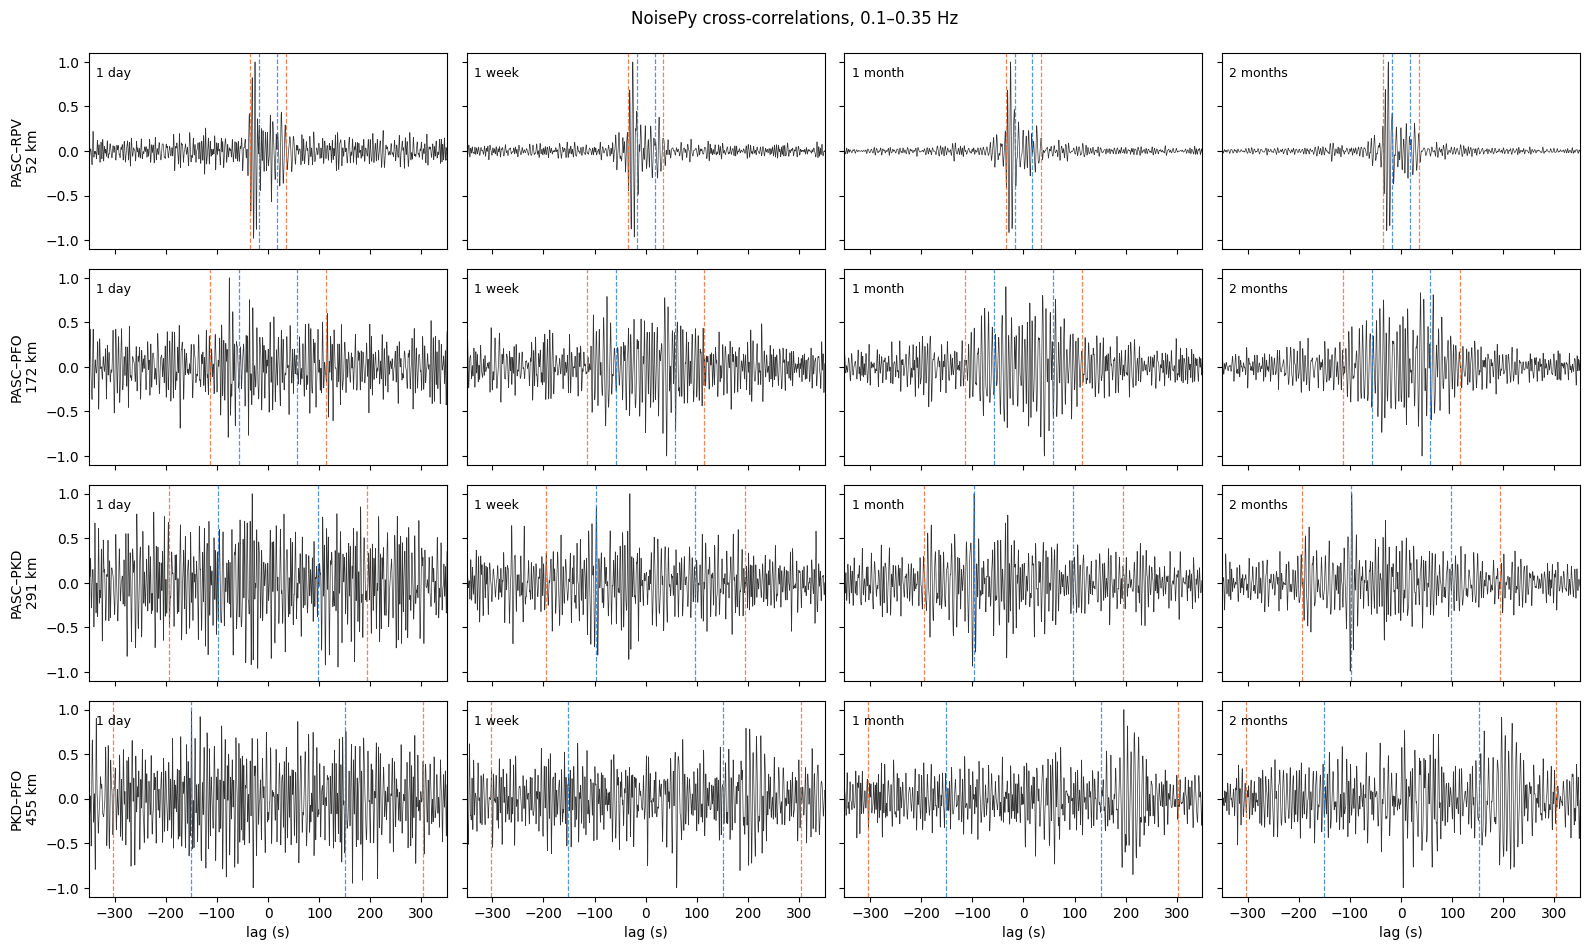

In [5]:
fig, axes = plt.subplots(len(PAIRS), 4, figsize=(16, 9.5), sharex=True, sharey=True)
order = sorted(PAIRS, key=lambda p: DIST[p])
for row, (s, r) in zip(axes, order):
    d = DIST[(s, r)]
    for ax, (lbl, days) in zip(row, STACKS):
        c = bp(stack_over((s, r), days))
        ax.plot(lag, c / np.abs(c).max(), lw=0.5, color="#333")
        for v, col in ((3.0, "#2a78d6"), (1.5, "#eb6834")):
            for sign in (+1, -1):
                ax.axvline(sign * d / v, color=col, lw=0.9, ls="--", alpha=0.8)
        ax.text(0.02, 0.93, lbl, transform=ax.transAxes, va="top", fontsize=9)
    row[0].set_ylabel(f"{s}–{r}\n{d:.0f} km")
for ax in axes[-1]:
    ax.set_xlabel("lag (s)")
    ax.set_xlim(-350, 350)
axes[0, 0].set_ylim(-1.1, 1.1)
fig.suptitle(f"NoisePy cross-correlations, {BAND[0]}–{BAND[1]} Hz", y=0.995)
fig.tight_layout()

## Record section: two-month-stacked CCFs vs distance

Folding the causal and acausal sides onto each other gains another √2 in
signal-to-noise and puts all three pairs on one distance axis.


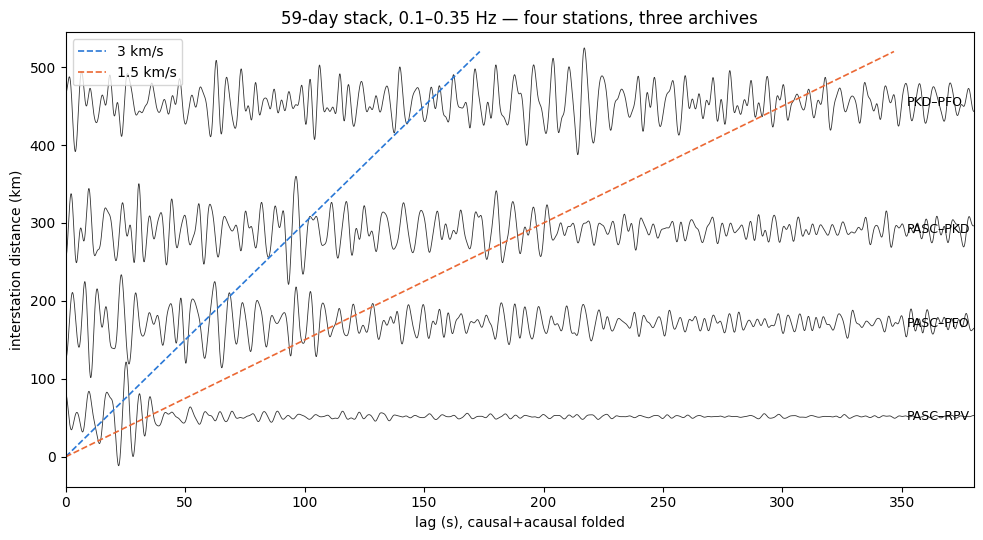

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for s, r in order:
    d = DIST[(s, r)]
    c = bp(stack_over((s, r), DAYS))
    n2 = c.size // 2
    fold = 0.5 * (c[n2:] + c[n2::-1][: c[n2:].size])
    tl = np.arange(fold.size) / cfg.sampling_rate
    ax.plot(tl, d + 70 * fold / np.abs(fold).max(), lw=0.6, color="#333")
    ax.text(352, d, f"{s}–{r}", va="center", fontsize=9)
dd = np.linspace(0, 520, 10)
for v, col, lbl in ((3.0, "#2a78d6", "3 km/s"), (1.5, "#eb6834", "1.5 km/s")):
    ax.plot(dd / v, dd, col, lw=1.2, ls="--", label=lbl)
ax.set_xlim(0, 380)
ax.set_ylim(min(DIST.values()) - 90, max(DIST.values()) + 90)
ax.set_xlabel("lag (s), causal+acausal folded")
ax.set_ylabel("interstation distance (km)")
ax.set_title(
    f"{len(DAYS)}-day stack, {BAND[0]}–{BAND[1]} Hz — four stations, three archives"
)
ax.legend(loc="upper left")
fig.tight_layout()

Energy concentrates between the 3 km/s and 1.5 km/s moveouts on all three
pairs — interstation Rayleigh waves extracted from two months of noise
spanning three cloud archives, without a single obspy call in the chain. The
52-km PASC–RPV path crosses the Los Angeles basin, whose slow sediments pull
the arrival toward the 1.5 km/s moveout.

**Provenance chain for these curves:**

1. `seisfetch.s3.S3OpenClient` — owns the three archives' key layouts
   (per-channel objects at SCEDC/NCEDC, station-day objects at EarthScope).
2. `seisfetch.convert.parse_mseed` — libmseed-backed decode, bit-identical
   to `obspy.read` (precision suite, `tests/precision/`).
3. `seisfetch.contrib.noisepy_adapter.preprocess_raw_np` — numpy ports of
   NoisePy's preprocessing, bit-identical through the resample and
   sub-sample-alignment branches.
4. NoisePy 0.9.93 `compute_fft` + `noise_module.correlate` — unchanged.

Cross-checked against the obspy-fed path in
`benchmarks/noisepy_eval/run_xcorr_eval.py`: **max abs difference 0.0** on
all three pairs.
